<a href="https://colab.research.google.com/github/Fatou-Kine3/github_task/blob/main/binary_classification_of_iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## Problem 1 – Select Features and Categories

In [1]:
from sklearn.datasets import load_iris

iris = load_iris()

In [2]:
print(iris.feature_names)
print(iris.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [3]:
import pandas as pd

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["target"] = iris.target

df = df[df["target"].isin([1, 2])]

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
50,7.0,3.2,4.7,1.4,1
51,6.4,3.2,4.5,1.5,1
52,6.9,3.1,4.9,1.5,1
53,5.5,2.3,4.0,1.3,1
54,6.5,2.8,4.6,1.5,1


In [4]:
X = df[["sepal length (cm)", "petal length (cm)"]]

y = df["target"]

In [5]:
print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
    sepal length (cm)  petal length (cm)
50                7.0                4.7
51                6.4                4.5
52                6.9                4.9
53                5.5                4.0
54                6.5                4.6

Target:
50    1
51    1
52    1
53    1
54    1
Name: target, dtype: int64


In [ ]:
### Observation

For this binary classification practice, we use two iris species: Versicolor and Virginica.

We select two features: Sepal Length and Petal Length. The target contains two classes, so this is a binary classification problem.

In [ ]:
## Problem 2 – Data Analysis

We visualize the selected data using a scatter plot, box plots, and violin plots.

In [2]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["target"] = iris.target

df = df[df["target"].isin([1, 2])]

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
50,7.0,3.2,4.7,1.4,1
51,6.4,3.2,4.5,1.5,1
52,6.9,3.1,4.9,1.5,1
53,5.5,2.3,4.0,1.3,1
54,6.5,2.8,4.6,1.5,1


In [3]:
df["species"] = df["target"].map({
    1: "versicolor",
    2: "virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
50,7.0,3.2,4.7,1.4,1,versicolor
51,6.4,3.2,4.5,1.5,1,versicolor
52,6.9,3.1,4.9,1.5,1,versicolor
53,5.5,2.3,4.0,1.3,1,versicolor
54,6.5,2.8,4.6,1.5,1,versicolor


In [4]:
X = df[["sepal length (cm)", "petal length (cm)"]]
y = df["target"]

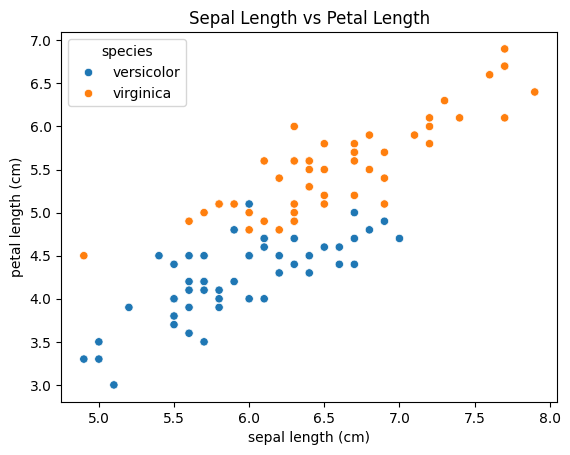

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x="sepal length (cm)",
    y="petal length (cm)",
    hue="species"
)

plt.title("Sepal Length vs Petal Length")
plt.show()

In [ ]:
## Problem 3 – Train/Validation Split

We split the data into training data and validation data.
75% of the data will be used for training and 25% for validation.

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X = df[["sepal length (cm)", "petal length (cm)"]]
y = df["target"]

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [9]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (75, 2)
X_val: (25, 2)
y_train: (75,)
y_val: (25,)


In [10]:
print("Training class ratio:")
print(y_train.value_counts())

print("\nValidation class ratio:")
print(y_val.value_counts())

Training class ratio:
target
2    38
1    37
Name: count, dtype: int64

Validation class ratio:
target
1    13
2    12
Name: count, dtype: int64


In [ ]:
### Observation

The dataset was divided into 75% training data and 25% validation data.
The `stratify=y` parameter preserves the proportion of Versicolor and Virginica in both subsets.

The `random_state` makes the split reproducible.

In [ ]:
## Problem 4 – Preprocessing and Standardization

We standardize the features using `StandardScaler`.

The scaler is fitted only on the training data to avoid data leakage. The same transformation is then applied to both the training and validation data.

In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
scaler = StandardScaler()

In [13]:
scaler.fit(X_train)

StandardScaler()

In [14]:
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [15]:
print("Before standardization:")
print(X_train.head())

print("\nAfter standardization:")
print(X_train_scaled[:5])

Before standardization:
     sepal length (cm)  petal length (cm)
111                6.4                5.3
121                5.6                4.9
65                 6.7                4.4
115                6.4                5.3
149                5.9                5.1

After standardization:
[[ 0.08837827  0.42173708]
 [-1.14480684 -0.0575096 ]
 [ 0.55082268 -0.65656795]
 [ 0.08837827  0.42173708]
 [-0.68236242  0.18211374]]


In [16]:
print("Mean:", X_train_scaled.mean(axis=0))
print("Standard deviation:", X_train_scaled.std(axis=0))

Mean: [2.12274642e-15 1.63128770e-15]
Standard deviation: [1. 1.]


In [ ]:
## Problem 5 – Training and Prediction

We use the k-nearest neighbors (k-NN) method for classification.

We test three values of `n_neighbors`: 5, 1, and 3.

In [17]:
from sklearn.neighbors import KNeighborsClassifier

In [18]:
knn_5 = KNeighborsClassifier(n_neighbors=5)

knn_5.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [19]:
y_pred_5 = knn_5.predict(X_val_scaled)

print(y_pred_5)

[2 2 1 1 2 2 1 2 2 2 1 2 1 1 2 1 1 2 1 2 1 2 2 1 2]


In [20]:
knn_1 = KNeighborsClassifier(n_neighbors=1)

knn_1.fit(X_train_scaled, y_train)

y_pred_1 = knn_1.predict(X_val_scaled)

print(y_pred_1)

[2 2 1 1 2 2 1 2 1 2 1 2 1 1 2 1 1 2 1 2 1 1 2 1 2]


In [21]:
knn_3 = KNeighborsClassifier(n_neighbors=3)

knn_3.fit(X_train_scaled, y_train)

y_pred_3 = knn_3.predict(X_val_scaled)

print(y_pred_3)

[2 2 1 1 2 2 2 2 2 2 1 2 1 1 2 1 1 2 1 2 1 2 2 1 2]


In [22]:
print("5-NN predictions:")
print(y_pred_5)

print("\n1-NN predictions:")
print(y_pred_1)

print("\n3-NN predictions:")
print(y_pred_3)

5-NN predictions:
[2 2 1 1 2 2 1 2 2 2 1 2 1 1 2 1 1 2 1 2 1 2 2 1 2]

1-NN predictions:
[2 2 1 1 2 2 1 2 1 2 1 2 1 1 2 1 1 2 1 2 1 1 2 1 2]

3-NN predictions:
[2 2 1 1 2 2 2 2 2 2 1 2 1 1 2 1 1 2 1 2 1 2 2 1 2]


In [ ]:
### Observation

We trained three k-NN models using 1, 3, and 5 neighbors.

The `predict()` method was used to classify the validation data. The predicted labels will be compared with the true validation labels in the next step to evaluate the models.

In [ ]:
## Problem 6 – Evaluation

We evaluate the k-NN models using accuracy, precision, recall, F1-score, and a confusion matrix.

In this analysis, Virginica (class 2) is considered the positive class.

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [24]:
print("5-NN")

print("Accuracy:", accuracy_score(y_val, y_pred_5))
print("Precision:", precision_score(y_val, y_pred_5, pos_label=2))
print("Recall:", recall_score(y_val, y_pred_5, pos_label=2))
print("F1-score:", f1_score(y_val, y_pred_5, pos_label=2))

5-NN
Accuracy: 0.84
Precision: 0.7857142857142857
Recall: 0.9166666666666666
F1-score: 0.8461538461538461


In [25]:
print("3-NN")

print("Accuracy:", accuracy_score(y_val, y_pred_3))
print("Precision:", precision_score(y_val, y_pred_3, pos_label=2))
print("Recall:", recall_score(y_val, y_pred_3, pos_label=2))
print("F1-score:", f1_score(y_val, y_pred_3, pos_label=2))

3-NN
Accuracy: 0.8
Precision: 0.7333333333333333
Recall: 0.9166666666666666
F1-score: 0.8148148148148148


In [26]:
print("1-NN")

print("Accuracy:", accuracy_score(y_val, y_pred_1))
print("Precision:", precision_score(y_val, y_pred_1, pos_label=2))
print("Recall:", recall_score(y_val, y_pred_1, pos_label=2))
print("F1-score:", f1_score(y_val, y_pred_1, pos_label=2))

1-NN
Accuracy: 0.84
Precision: 0.8333333333333334
Recall: 0.8333333333333334
F1-score: 0.8333333333333334


In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred_5)

print(cm)

[[10  3]
 [ 1 11]]


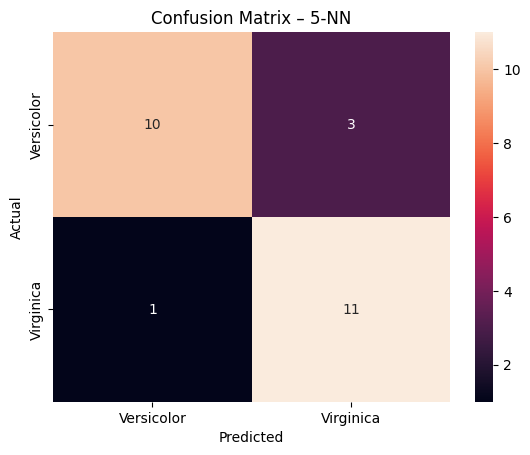

In [29]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Versicolor", "Virginica"],
    yticklabels=["Versicolor", "Virginica"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – 5-NN")
plt.show()

In [ ]:
### Meaning of the Evaluation Metrics

**Accuracy:** The proportion of all predictions that are correct.

**Precision:** Among the samples predicted as Virginica, the proportion that are actually Virginica.

**Recall:** Among the actual Virginica samples, the proportion that are correctly identified.

**F1-score:** The harmonic mean of precision and recall.

In this analysis, Virginica (class 2) is considered the positive class.

In [ ]:
## Problem 7 – Visualization

We visualize the decision regions of the k-NN model using the two selected features.

The background shows the predicted class, while the points show the actual data.

In [30]:
knn_3 = KNeighborsClassifier(n_neighbors=3)

knn_3.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=3)

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches


def decision_region(
    X,
    y,
    model,
    step=0.01,
    title="decision region",
    xlabel="xlabel",
    ylabel="ylabel",
    target_names=None,
):
    """
    Draw the determination area of the model that learned binary classification with two-dimensional features.
    The background color is drawn from the estimated values of the trained model.
    The points on the scatter plot are training or validation data.

    Parameters
    ----------------
    X : ndarray, shape(n_samples, 2)
        Feature value
    y : ndarray, shape(n_samples,)
        label
    model : object
        Insert the installed model of the learned model
    step : float, (default : 0.1)
        Set the interval to calculate the estimate
    title : str
        Give the text of the graph Title
    xlabel, ylabel : str
        Give the text of the axis label
    target_names= : list of str
        Give a list of legends
    """
    if target_names is None:
        target_names = ["versicolor", "virginica"]

    # setting
    scatter_color = ["red", "blue"]
    contourf_color = ["pink", "skyblue"]
    n_class = 2

    # pred
    mesh_f0, mesh_f1 = np.meshgrid(
        np.arange(np.min(X[:, 0]) - 0.5, np.max(X[:, 0]) + 0.5, step),
        np.arange(np.min(X[:, 1]) - 0.5, np.max(X[:, 1]) + 0.5, step),
    )
    mesh = np.c_[np.ravel(mesh_f0), np.ravel(mesh_f1)]
    y_pred = model.predict(mesh).reshape(mesh_f0.shape)

    # plot
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.contourf(
        mesh_f0, mesh_f1, y_pred, n_class - 1, cmap=ListedColormap(contourf_color)
    )
    plt.contour(
        mesh_f0, mesh_f1, y_pred, n_class - 1, colors="y", linewidths=3, alpha=0.5
    )
    for i, target in enumerate(np.unique(y)):
        plt.scatter(
            X[y == target][:, 0],
            X[y == target][:, 1],
            s=80,
            color=scatter_color[i],
            label=target_names[i],
            marker="o",
        )
    patches = [
        mpatches.Patch(color=scatter_color[i], label=target_names[i])
        for i in range(n_class)
    ]
    plt.legend(handles=patches)
    plt.legend()
    plt.show()


In [33]:
print(decision_region)

<function decision_region at 0x78557593aac0>


In [34]:
knn_3 = KNeighborsClassifier(n_neighbors=3)
knn_3.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=3)

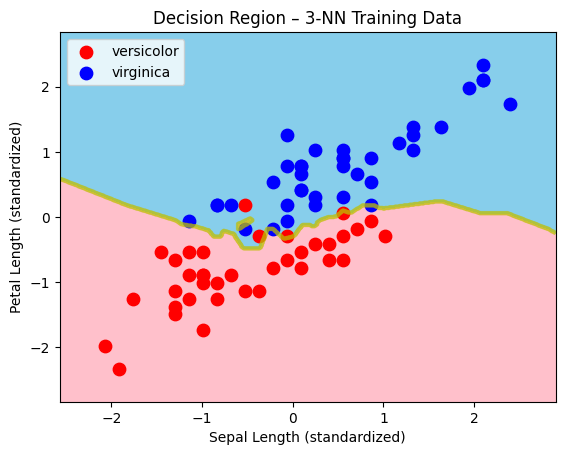

In [35]:
decision_region(
    X_train_scaled,
    y_train.to_numpy(),
    knn_3,
    title="Decision Region – 3-NN Training Data",
    xlabel="Sepal Length (standardized)",
    ylabel="Petal Length (standardized)",
    target_names=["versicolor", "virginica"]
)

In [ ]:
## Problem 8 – Comparison of Classification Methods

We compare five classification methods:

- k-Nearest Neighbors
- Logistic Regression
- Support Vector Machine
- Decision Tree
- Random Forest

The same training and validation datasets are used for all models.

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [37]:
logistic = LogisticRegression(random_state=42)

logistic.fit(X_train_scaled, y_train)

y_pred_logistic = logistic.predict(X_val_scaled)

In [38]:
svm = SVC()

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_val_scaled)

In [39]:
tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train_scaled, y_train)

y_pred_tree = tree.predict(X_val_scaled)

In [40]:
forest = RandomForestClassifier(random_state=42)

forest.fit(X_train_scaled, y_train)

y_pred_forest = forest.predict(X_val_scaled)

In [41]:
models_predictions = {
    "Logistic Regression": y_pred_logistic,
    "SVM": y_pred_svm,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_forest
}

for name, y_pred in models_predictions.items():
    print(name)
    print("Accuracy:", accuracy_score(y_val, y_pred))
    print("Precision:", precision_score(y_val, y_pred, pos_label=2))
    print("Recall:", recall_score(y_val, y_pred, pos_label=2))
    print("F1-score:", f1_score(y_val, y_pred, pos_label=2))
    print()

Logistic Regression
Accuracy: 0.92
Precision: 0.9166666666666666
Recall: 0.9166666666666666
F1-score: 0.9166666666666666

SVM
Accuracy: 0.88
Precision: 0.8461538461538461
Recall: 0.9166666666666666
F1-score: 0.88

Decision Tree
Accuracy: 0.84
Precision: 0.8333333333333334
Recall: 0.8333333333333334
F1-score: 0.8333333333333334

Random Forest
Accuracy: 0.88
Precision: 0.8461538461538461
Recall: 0.9166666666666666
F1-score: 0.88



In [42]:
results = []

# 5-NN
results.append([
    "5-NN",
    accuracy_score(y_val, y_pred_5),
    precision_score(y_val, y_pred_5, pos_label=2),
    recall_score(y_val, y_pred_5, pos_label=2),
    f1_score(y_val, y_pred_5, pos_label=2)
])

# Logistic Regression
results.append([
    "Logistic Regression",
    accuracy_score(y_val, y_pred_logistic),
    precision_score(y_val, y_pred_logistic, pos_label=2),
    recall_score(y_val, y_pred_logistic, pos_label=2),
    f1_score(y_val, y_pred_logistic, pos_label=2)
])

# SVM
results.append([
    "SVM",
    accuracy_score(y_val, y_pred_svm),
    precision_score(y_val, y_pred_svm, pos_label=2),
    recall_score(y_val, y_pred_svm, pos_label=2),
    f1_score(y_val, y_pred_svm, pos_label=2)
])

# Decision Tree
results.append([
    "Decision Tree",
    accuracy_score(y_val, y_pred_tree),
    precision_score(y_val, y_pred_tree, pos_label=2),
    recall_score(y_val, y_pred_tree, pos_label=2),
    f1_score(y_val, y_pred_tree, pos_label=2)
])

# Random Forest
results.append([
    "Random Forest",
    accuracy_score(y_val, y_pred_forest),
    precision_score(y_val, y_pred_forest, pos_label=2),
    recall_score(y_val, y_pred_forest, pos_label=2),
    f1_score(y_val, y_pred_forest, pos_label=2)
])

In [43]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=["Method", "Accuracy", "Precision", "Recall", "F1-score"]
)

results_df

,Method,Accuracy,Precision,Recall,F1-score
0,5-NN,0.84,0.785714,0.916667,0.846154
1,Logistic Regression,0.92,0.916667,0.916667,0.916667
2,SVM,0.88,0.846154,0.916667,0.880000
3,Decision Tree,0.84,0.833333,0.833333,0.833333
4,Random Forest,0.88,0.846154,0.916667,0.880000


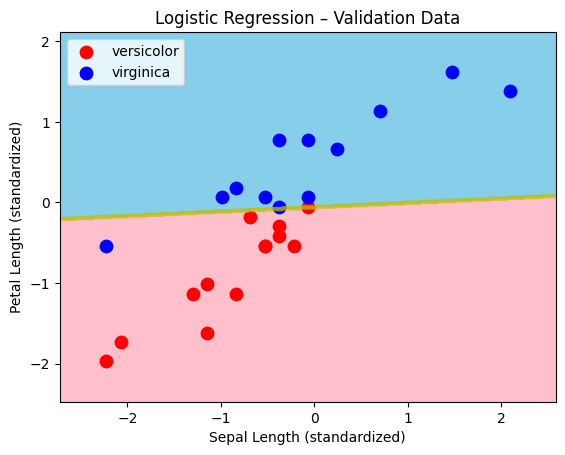

In [44]:
decision_region(
    X_val_scaled,
    y_val.to_numpy(),
    logistic,
    title="Logistic Regression – Validation Data",
    xlabel="Sepal Length (standardized)",
    ylabel="Petal Length (standardized)",
    target_names=["versicolor", "virginica"]
)

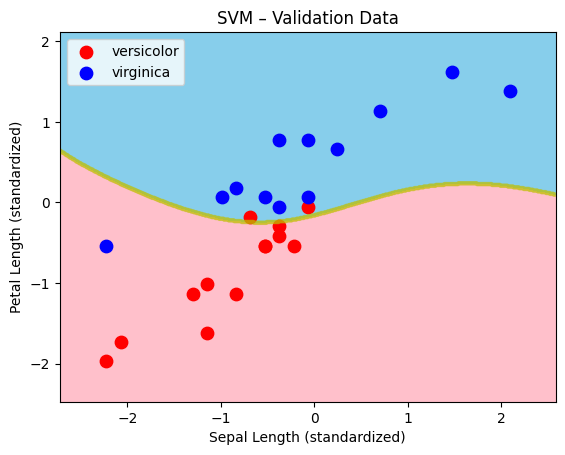

In [45]:
decision_region(
    X_val_scaled,
    y_val.to_numpy(),
    svm,
    title="SVM – Validation Data",
    xlabel="Sepal Length (standardized)",
    ylabel="Petal Length (standardized)",
    target_names=["versicolor", "virginica"]
)

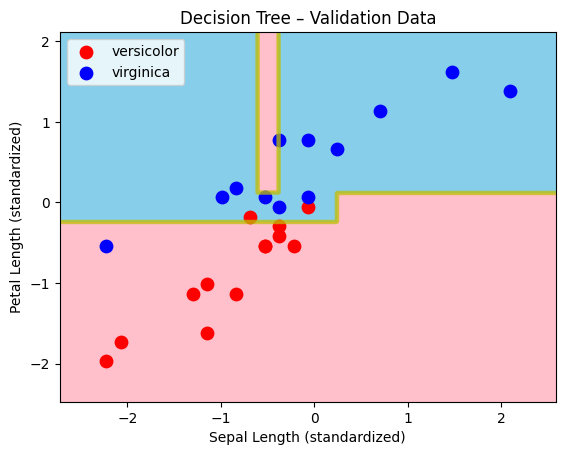

In [46]:
decision_region(
    X_val_scaled,
    y_val.to_numpy(),
    tree,
    title="Decision Tree – Validation Data",
    xlabel="Sepal Length (standardized)",
    ylabel="Petal Length (standardized)",
    target_names=["versicolor", "virginica"]
)

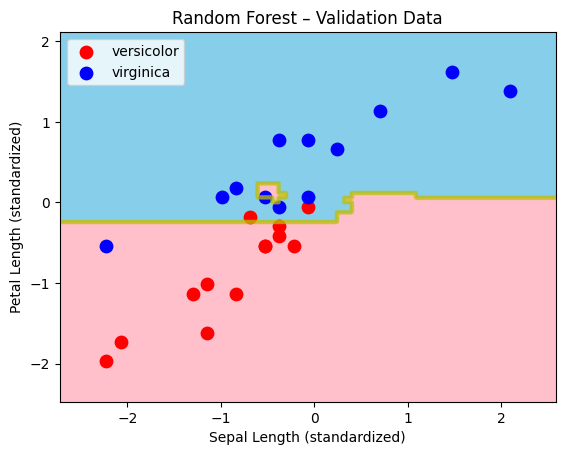

In [47]:
decision_region(
    X_val_scaled,
    y_val.to_numpy(),
    forest,
    title="Random Forest – Validation Data",
    xlabel="Sepal Length (standardized)",
    ylabel="Petal Length (standardized)",
    target_names=["versicolor", "virginica"]
)

In [ ]:
### Discussion

The five classification methods were evaluated using the same training and validation data.

The best method depends on the evaluation metric. Accuracy shows the overall proportion of correct predictions, while precision, recall, and F1-score focus on the positive class, Virginica.

The decision regions also show that different methods create different classification boundaries. Some methods produce relatively simple boundaries, while tree-based methods can create more complex boundaries.

Based on the results, the method with the highest value for each metric can be identified from the comparison table.

In [ ]:
## Problem 9 – Comparison With and Without Standardization

We compare the classification results with and without standardization.

The same training and validation datasets are used for both experiments.

In [48]:
knn_5_raw = KNeighborsClassifier(n_neighbors=5)
knn_5_raw.fit(X_train, y_train)
y_pred_knn_raw = knn_5_raw.predict(X_val)

In [49]:
logistic_raw = LogisticRegression(random_state=42)
logistic_raw.fit(X_train, y_train)
y_pred_logistic_raw = logistic_raw.predict(X_val)

In [50]:
svm_raw = SVC()
svm_raw.fit(X_train, y_train)
y_pred_svm_raw = svm_raw.predict(X_val)

In [51]:
tree_raw = DecisionTreeClassifier(random_state=42)
tree_raw.fit(X_train, y_train)
y_pred_tree_raw = tree_raw.predict(X_val)

In [52]:
forest_raw = RandomForestClassifier(random_state=42)
forest_raw.fit(X_train, y_train)
y_pred_forest_raw = forest_raw.predict(X_val)

In [53]:
results_raw = []

models_raw = {
    "5-NN": y_pred_knn_raw,
    "Logistic Regression": y_pred_logistic_raw,
    "SVM": y_pred_svm_raw,
    "Decision Tree": y_pred_tree_raw,
    "Random Forest": y_pred_forest_raw
}

for name, y_pred in models_raw.items():
    results_raw.append([
        name,
        accuracy_score(y_val, y_pred),
        precision_score(y_val, y_pred, pos_label=2),
        recall_score(y_val, y_pred, pos_label=2),
        f1_score(y_val, y_pred, pos_label=2)
    ])

results_raw_df = pd.DataFrame(
    results_raw,
    columns=["Method", "Accuracy", "Precision", "Recall", "F1-score"]
)

results_raw_df

,Method,Accuracy,Precision,Recall,F1-score
0,5-NN,0.84,0.785714,0.916667,0.846154
1,Logistic Regression,0.96,1.000000,0.916667,0.956522
2,SVM,0.88,0.846154,0.916667,0.880000
3,Decision Tree,0.84,0.833333,0.833333,0.833333
4,Random Forest,0.88,0.846154,0.916667,0.880000


In [54]:
results_df

,Method,Accuracy,Precision,Recall,F1-score
0,5-NN,0.84,0.785714,0.916667,0.846154
1,Logistic Regression,0.92,0.916667,0.916667,0.916667
2,SVM,0.88,0.846154,0.916667,0.880000
3,Decision Tree,0.84,0.833333,0.833333,0.833333
4,Random Forest,0.88,0.846154,0.916667,0.880000


In [55]:
comparison = results_df.merge(
    results_raw_df,
    on="Method",
    suffixes=("_scaled", "_raw")
)

comparison

,Method,Accuracy_scaled,Precision_scaled,Recall_scaled,F1-score_scaled,Accuracy_raw,Precision_raw,Recall_raw,F1-score_raw
0,5-NN,0.84,0.785714,0.916667,0.846154,0.84,0.785714,0.916667,0.846154
1,Logistic Regression,0.92,0.916667,0.916667,0.916667,0.96,1.000000,0.916667,0.956522
2,SVM,0.88,0.846154,0.916667,0.880000,0.88,0.846154,0.916667,0.880000
3,Decision Tree,0.84,0.833333,0.833333,0.833333,0.84,0.833333,0.833333,0.833333
4,Random Forest,0.88,0.846154,0.916667,0.880000,0.88,0.846154,0.916667,0.880000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


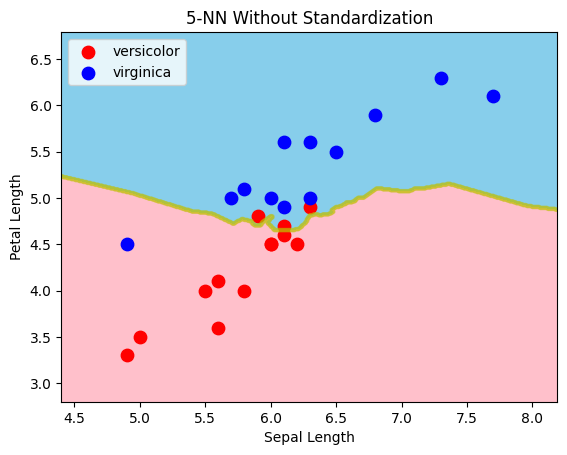

In [57]:
decision_region(
    X_val.to_numpy(),
    y_val.to_numpy(),
    knn_5_raw,
    title="5-NN Without Standardization",
    xlabel="Sepal Length",
    ylabel="Petal Length",
    target_names=["versicolor", "virginica"]
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


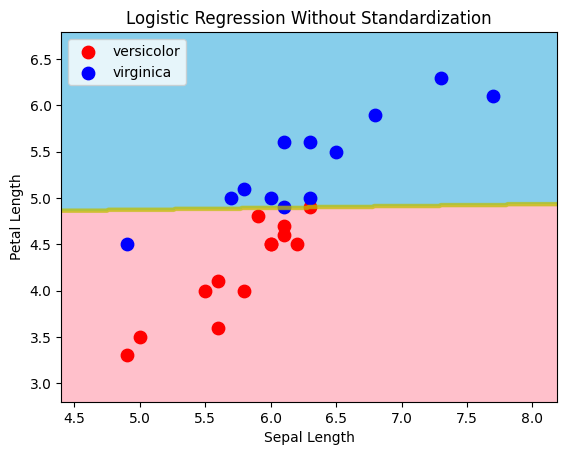

In [58]:
decision_region(
    X_val.to_numpy(),
    y_val.to_numpy(),
    logistic_raw,
    title="Logistic Regression Without Standardization",
    xlabel="Sepal Length",
    ylabel="Petal Length",
    target_names=["versicolor", "virginica"]
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


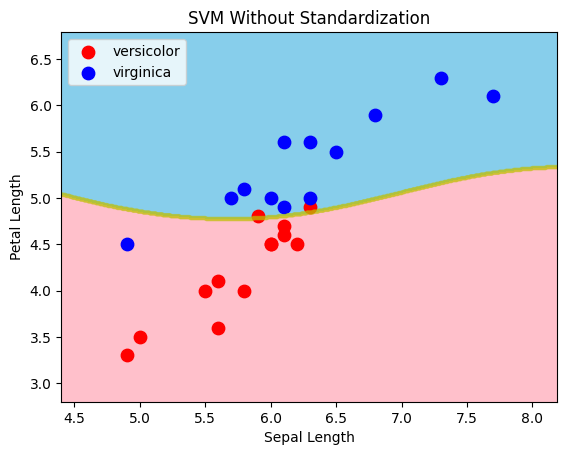

In [59]:
decision_region(
    X_val.to_numpy(),
    y_val.to_numpy(),
    svm_raw,
    title="SVM Without Standardization",
    xlabel="Sepal Length",
    ylabel="Petal Length",
    target_names=["versicolor", "virginica"]
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


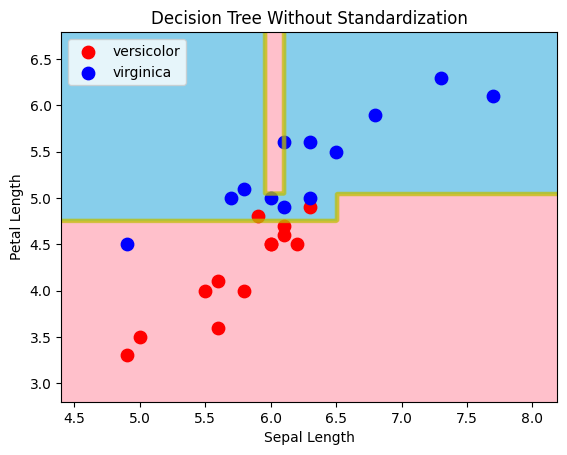

In [60]:
decision_region(
    X_val.to_numpy(),
    y_val.to_numpy(),
    tree_raw,
    title="Decision Tree Without Standardization",
    xlabel="Sepal Length",
    ylabel="Petal Length",
    target_names=["versicolor", "virginica"]
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


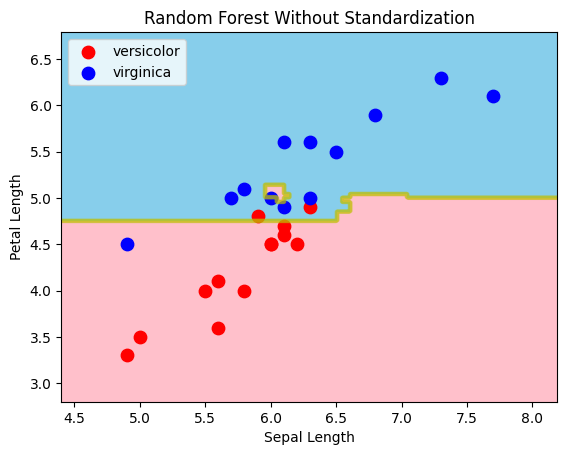

In [61]:
decision_region(
    X_val.to_numpy(),
    y_val.to_numpy(),
    forest_raw,
    title="Random Forest Without Standardization",
    xlabel="Sepal Length",
    ylabel="Petal Length",
    target_names=["versicolor", "virginica"]
)

In [62]:
X = iris.data
y = iris.target

In [63]:
print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [65]:
from sklearn.model_selection import train_test_split

X_train_multi, X_val_multi, y_train_multi, y_val_multi = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [66]:
from sklearn.preprocessing import StandardScaler

scaler_multi = StandardScaler()

X_train_multi_scaled = scaler_multi.fit_transform(X_train_multi)
X_val_multi_scaled = scaler_multi.transform(X_val_multi)

In [67]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [68]:
models_multi = {
    "5-NN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(random_state=42),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

In [69]:
predictions_multi = {}

for name, model in models_multi.items():
    model.fit(X_train_multi_scaled, y_train_multi)
    predictions_multi[name] = model.predict(X_val_multi_scaled)

In [70]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [71]:
results_multi = []

for name, y_pred in predictions_multi.items():

    accuracy = accuracy_score(y_val_multi, y_pred)

    precision_macro = precision_score(
        y_val_multi, y_pred, average="macro"
    )

    recall_macro = recall_score(
        y_val_multi, y_pred, average="macro"
    )

    f1_macro = f1_score(
        y_val_multi, y_pred, average="macro"
    )

    precision_micro = precision_score(
        y_val_multi, y_pred, average="micro"
    )

    recall_micro = recall_score(
        y_val_multi, y_pred, average="micro"
    )

    f1_micro = f1_score(
        y_val_multi, y_pred, average="micro"
    )

    results_multi.append([
        name,
        accuracy,
        precision_macro,
        recall_macro,
        f1_macro,
        precision_micro,
        recall_micro,
        f1_micro
    ])

In [72]:
results_multi_df = pd.DataFrame(
    results_multi,
    columns=[
        "Method",
        "Accuracy",
        "Precision Macro",
        "Recall Macro",
        "F1 Macro",
        "Precision Micro",
        "Recall Micro",
        "F1 Micro"
    ]
)

results_multi_df

,Method,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Micro,Recall Micro,F1 Micro
0,5-NN,0.921053,0.937500,0.923077,0.922039,0.921053,0.921053,0.921053
1,Logistic Regression,0.921053,0.924603,0.923077,0.922963,0.921053,0.921053,0.921053
2,SVM,0.947368,0.948718,0.948718,0.948718,0.947368,0.947368,0.947368
3,Decision Tree,0.894737,0.903030,0.897436,0.896825,0.894737,0.894737,0.894737
4,Random Forest,0.921053,0.924603,0.923077,0.922963,0.921053,0.921053,0.921053


In [73]:
best_model = results_multi_df.loc[
    results_multi_df["Accuracy"].idxmax()
]

best_model

,2
Method,SVM
Accuracy,0.947368
Precision Macro,0.948718
Recall Macro,0.948718
F1 Macro,0.948718
Precision Micro,0.947368
Recall Micro,0.947368
F1 Micro,0.947368


In [ ]:
### Macro vs Micro averaging

Macro averaging calculates the metric independently for each class and then takes the average. Therefore, each class has the same importance.

Micro averaging combines the predictions of all classes before calculating the metric. Therefore, each individual sample has the same importance.

In this single-label multiclass classification problem, micro-averaged precision, recall and F1-score are equal to accuracy when all classes are included.

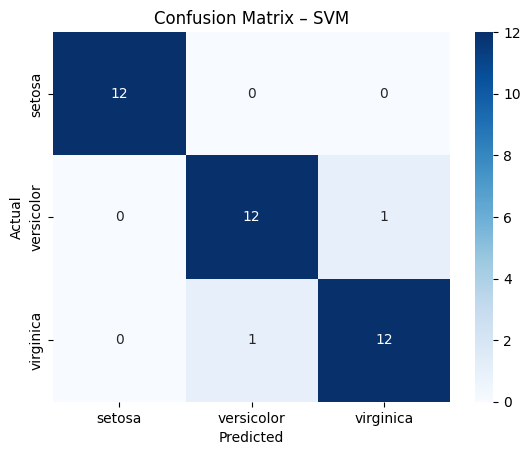

In [74]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_val_multi,
    predictions_multi["SVM"]
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – SVM")
plt.show()

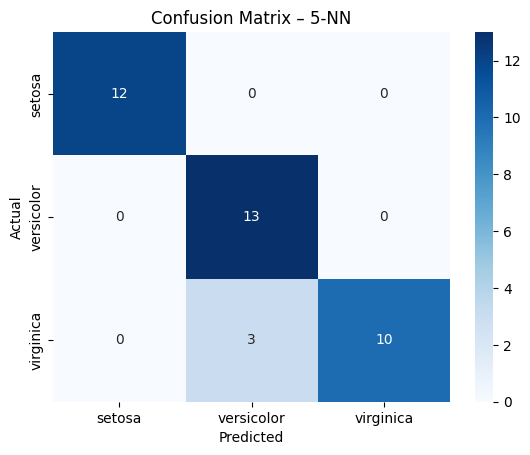

In [76]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_val_multi,
    predictions_multi["5-NN"]
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – 5-NN")
plt.show()

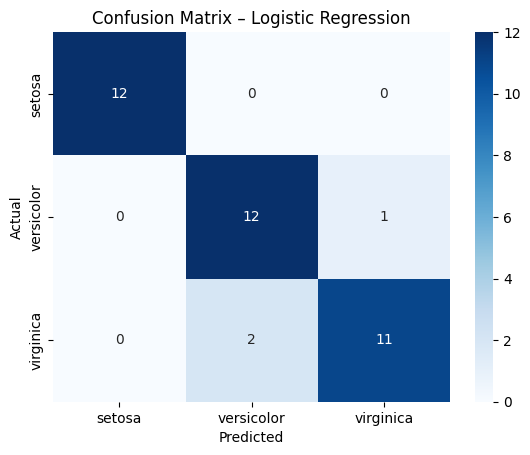

In [78]:
cm = confusion_matrix(
    y_val_multi,
    predictions_multi["Logistic Regression"]
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Logistic Regression")
plt.show()

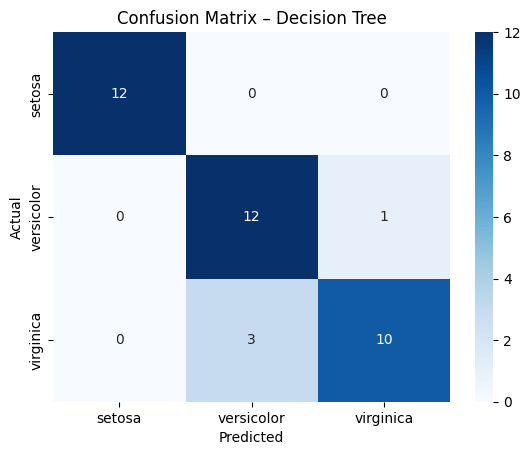

In [79]:
cm = confusion_matrix(
    y_val_multi,
    predictions_multi["Decision Tree"]
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Decision Tree")
plt.show()

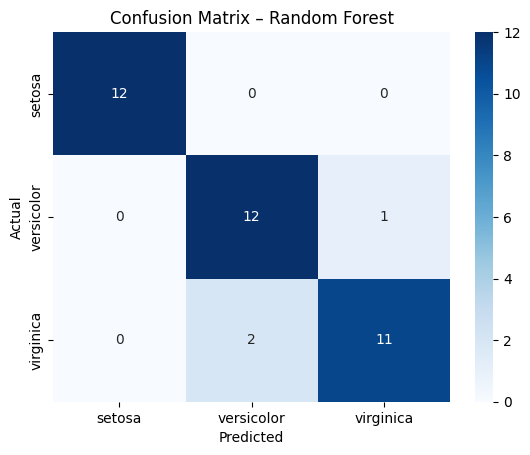

In [80]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_val_multi,
    predictions_multi["Random Forest"]
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Random Forest")
plt.show()

In [ ]:
### Discussion

The five methods were compared using the same training and validation datasets.

The model with the highest validation accuracy was the best-performing method for this experiment.

The macro-average gives equal importance to the three iris classes, while the micro-average considers all individual predictions together.

In this single-label multiclass classification problem, the micro-averaged precision, recall and F1-score are equal to accuracy.

The results show that the different methods can achieve different performances, even when they are trained and evaluated under the same conditions.